<a href="https://colab.research.google.com/github/nohaelkachach/casiav2-splicing-gradcam-audit/blob/main/notebooks/06_channel_dilution_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Channel-dilution mechanism audit

**What this notebook tests:** notebook 05 found that the polarity-by-size interaction is strong on ResNet18 but weak/non-significant on EfficientNet-B0. This notebook tests one specific, pre-specified explanation: EfficientNet-B0's target layer has 2.5x more channels (1280 vs. 512) than ResNet18's, so Grad-CAM's channel-averaged weighting may dilute a narrow polarity-carrying signal more on EfficientNet-B0.

**The test:** recompute EfficientNet-B0's Grad-CAM using only its top-512 gradient-weighted channels (matching ResNet18's channel count) instead of all 1280, and check whether the interaction strengthens. This is a single, pre-specified prediction — not a search for a specification that produces significance — so the result is reported honestly whichever way it comes out.

**Result of running this once already:** the interaction strengthened (coef -0.028, p=0.011 → coef -0.048, p<0.001), supporting channel-count dilution as a real contributor to the architecture-dependence. This notebook is the clean, documented version of that test for reproducibility.

## Path reference — what each file is and where it comes from

| Variable | What it is | Produced by |
|---|---|---|
| `base` | Root folder of the CASIA v2 image set (`Tp`, `Au`, list files) | Your own Drive upload |
| `tp_dir` | Folder of tampered (copy-move + spliced) images | Subfolder of `base` |
| `gt_dir` | Folder of ground-truth tampering masks | Your own Drive upload (Pham et al. groundtruth) |
| `casia_effnet_best.pt` | Trained EfficientNet-B0 classifier weights | Notebook 03 |
| `splice_features.csv` | Per-image splice_size_frac, polarity, abs_contrast | Notebook 02 |
| `gradcam_iou_effnet.csv` | Standard (all-1280-channel) Grad-CAM IoU, EfficientNet-B0 | Notebook 04 |
| `gradcam_iou_effnet_top512.csv` | **New in this notebook** — top-512-channel-restricted Grad-CAM IoU | This notebook, saved at the end |

Adjust `base` and `gt_dir` below to match your own Drive layout — they should be identical to the paths used in notebooks 01–04.

## Setup — mount Drive, rebuild file lists, load EfficientNet-B0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import statsmodels.formula.api as smf
from PIL import Image

# --- Same paths as notebooks 01-04. Adjust if your Drive layout differs. ---
base = "/content/drive/MyDrive/CASIA2.0/CASIA2.0_revised"
tp_dir = os.path.join(base, "Tp")
gt_dir = "/content/drive/MyDrive/CASIA2.0/CASIA2.0_Groundtruth/CASIA2.0_Groundtruth"

with open(os.path.join(base, "tp_list.txt")) as f:
    tp_list_content = [line.strip() for line in f if line.strip()]
tp_files_final = sorted(set(tp_list_content) & set(os.listdir(tp_dir)))
spliced_files = [f for f in tp_files_final if f.split("_")[1] == "D"]
print(f"Spliced-only file count: {len(spliced_files)}")  # expect 1828

def get_mask_path(image_filename):
    stem = os.path.splitext(image_filename)[0]
    return os.path.join(gt_dir, f"{stem}_gt.png")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# --- Local copy of Tp images for faster repeated reads across many Grad-CAM passes ---
import shutil
local_tp_dir = "/content/casia_local_tp"
if not os.path.exists(local_tp_dir):
    print("Copying Tp folder to local disk...")
    shutil.copytree(tp_dir, local_tp_dir)
print(f"Local file count: {len(os.listdir(local_tp_dir))}")

# --- Load the same trained EfficientNet-B0 checkpoint used in notebooks 03-05 ---
effnet = models.efficientnet_b0(weights=None)
num_features = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_features, 2)
effnet.load_state_dict(torch.load("/content/drive/MyDrive/CASIA2.0/casia_effnet_best.pt", map_location=device))
effnet = effnet.to(device)
effnet.eval()
print("EfficientNet-B0 checkpoint loaded.")

# --- Also load ResNet18 briefly, just to verify the channel-count premise this notebook tests ---
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load("/content/drive/MyDrive/CASIA2.0/casia_resnet_best.pt", map_location=device))
resnet = resnet.to(device)
resnet.eval()

print(f"\nResNet18 target layer channels: {resnet.layer4[-1].conv2.out_channels}")
print(f"EfficientNet-B0 target layer channels: {effnet.features[-1][0].out_channels}")

Mounted at /content/drive
Spliced-only file count: 1828
Device: cuda
Copying Tp folder to local disk...
Local file count: 5123
EfficientNet-B0 checkpoint loaded.

ResNet18 target layer channels: 512
EfficientNet-B0 target layer channels: 1280


## Top-K restricted Grad-CAM
Same mechanism as standard Grad-CAM (forward/backward hooks, channel-wise gradient averaging), except only the `top_k` channels with the largest |weight| contribute — all other channels are zeroed out before the weighted sum. Setting `top_k=512` matches ResNet18's channel count exactly.

In [ ]:
class GradCAM_TopK:
    def __init__(self, model, target_layer, top_k=None):
        self.model = model
        self.gradients = None
        self.activations = None
        self.top_k = top_k
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        if self.top_k is not None:
            flat_weights = weights.squeeze().abs()
            k = min(self.top_k, flat_weights.shape[0])
            topk_idx = torch.topk(flat_weights, k).indices
            mask = torch.zeros_like(flat_weights)
            mask[topk_idx] = 1.0
            weights = weights * mask.view(1, -1, 1, 1)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

gradcam_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def compute_iou(cam, gt_mask_binary):
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize(
        (gt_mask_binary.shape[1], gt_mask_binary.shape[0]), Image.BILINEAR
    )) / 255.0
    thresh = cam_resized.mean()
    cam_binary = cam_resized > thresh
    intersection = np.logical_and(cam_binary, gt_mask_binary).sum()
    union = np.logical_or(cam_binary, gt_mask_binary).sum()
    if union == 0:
        return None
    return intersection / union

## Run top-512 restricted Grad-CAM + IoU on all 1,828 spliced images

In [ ]:
gradcam_effnet_topk = GradCAM_TopK(effnet, effnet.features[-1], top_k=512)

records_topk = []
for i, fname in enumerate(spliced_files):
    img_path = os.path.join(tp_dir, fname)
    mask_path = get_mask_path(fname)
    if not os.path.exists(mask_path):
        continue

    img_pil = Image.open(img_path).convert("RGB")
    input_tensor = gradcam_transform(img_pil).unsqueeze(0).to(device)
    cam = gradcam_effnet_topk.generate(input_tensor, target_class=1)

    orig_size = img_pil.size
    mask_pil = Image.open(mask_path).convert("L").resize(orig_size, Image.NEAREST)
    gt_mask_binary = np.array(mask_pil) > 127

    iou = compute_iou(cam, gt_mask_binary)
    if iou is None:
        continue

    records_topk.append({"filename": fname, "iou": iou})
    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(spliced_files)}")

iou_df_topk = pd.DataFrame(records_topk)
iou_df_topk.to_csv("/content/drive/MyDrive/CASIA2.0/gradcam_iou_effnet_top512.csv", index=False)
print(f"\nDone. {len(iou_df_topk)} of {len(spliced_files)} images.")
print(iou_df_topk.describe())

Processed 200/1828
Processed 400/1828
Processed 600/1828
Processed 800/1828
Processed 1000/1828
Processed 1200/1828
Processed 1400/1828
Processed 1600/1828
Processed 1800/1828

Done. 1828 of 1828 images.
               iou
count  1828.000000
mean      0.163725
std       0.164773
min       0.000000
25%       0.033126
50%       0.107635
75%       0.253087
max       0.872692


## Compare: standard (1280-channel) vs. top-512-restricted regression
Same median-split moderation model as notebook 05, run on the top-512 IoU values, for direct comparison against the standard EfficientNet-B0 result already obtained.

In [ ]:
features_df = pd.read_csv("/content/drive/MyDrive/CASIA2.0/splice_features.csv")

merged_topk = features_df.merge(iou_df_topk, on="filename", how="inner")
merged_topk["polarity_bin"] = (merged_topk["polarity"] == "dark_on_bright").astype(int)
median_size_topk = merged_topk["splice_size_frac"].median()
merged_topk["large_splice_median"] = (merged_topk["splice_size_frac"] >= median_size_topk).astype(int)

model_topk = "iou ~ polarity_bin * large_splice_median + abs_contrast"
ols_topk = smf.ols(formula=model_topk, data=merged_topk).fit(cov_type="HC3")
print("=== EfficientNet-B0, top-512 channels, median split ===")
print(ols_topk.summary().tables[1])

print("\nCompare against the standard (1280-channel) result from notebook 05:")
print("polarity_bin:large_splice_median = -0.0279, p=0.011 (standard, full channels)")

=== EfficientNet-B0, top-512 channels, median split ===
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.0457      0.005     10.112      0.000       0.037       0.055
polarity_bin                         0.0003      0.003      0.086      0.931      -0.006       0.007
large_splice_median                  0.2387      0.008     29.218      0.000       0.223       0.255
polarity_bin:large_splice_median    -0.0476      0.011     -4.232      0.000      -0.070      -0.026
abs_contrast                         0.0002   8.33e-05      2.297      0.022    2.81e-05       0.000

Compare against the standard (1280-channel) result from notebook 05:
polarity_bin:large_splice_median = -0.0279, p=0.011 (standard, full channels)


## Robustness check: random-channel control

The top-512 test above changes two things at once: how many channels contribute, and *which* channels (the highest gradient-weighted ones). This cell isolates channel *count* alone by restricting to 10 independently-drawn **random** 512-channel subsets (not selected by gradient magnitude) and comparing their regression output against both the standard (1280-channel) and top-512 (gradient-selected) results above.

- If random-512 subsets also strengthen the effect relative to the full 1280-channel baseline, that supports channel-count dilution as a real, general contributor.
- If random-512 looks the same as random-512 but weaker than top-512, that indicates the polarity signal is concentrated in specific high-gradient channels, on top of a general dilution effect — both mechanisms contributing, not either/or.

In [ ]:
import random

class GradCAM_RandomK:
    """Grad-CAM restricted to a RANDOM subset of k channels (not chosen by
    gradient magnitude) — the control condition for the top-K dilution test."""
    def __init__(self, model, target_layer, k):
        self.model = model
        self.gradients = None
        self.activations = None
        self.k = k
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        n_channels = weights.shape[1]

        random_idx = random.sample(range(n_channels), self.k)
        mask = torch.zeros(n_channels, device=weights.device)
        mask[random_idx] = 1.0
        weights = weights * mask.view(1, -1, 1, 1)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


def run_random_channel_trial(model, target_layer, k, seed):
    random.seed(seed)
    gradcam_rand = GradCAM_RandomK(model, target_layer, k)
    records = []
    for fname in spliced_files:
        img_path = os.path.join(local_tp_dir, fname)
        mask_path = get_mask_path(fname)
        if not os.path.exists(mask_path):
            continue
        img_pil = Image.open(img_path).convert("RGB")
        input_tensor = gradcam_transform(img_pil).unsqueeze(0).to(device)
        cam = gradcam_rand.generate(input_tensor, target_class=1)
        orig_size = img_pil.size
        mask_pil = Image.open(mask_path).convert("L").resize(orig_size, Image.NEAREST)
        gt_mask_binary = np.array(mask_pil) > 127
        iou = compute_iou(cam, gt_mask_binary)
        if iou is None:
            continue
        records.append({"filename": fname, "iou": iou})
    return pd.DataFrame(records)


random_trial_results = []
for trial_seed in range(10):
    df_trial = run_random_channel_trial(effnet, effnet.features[-1], k=512, seed=trial_seed)
    merged_trial = features_df.merge(df_trial, on="filename", how="inner")
    merged_trial["polarity_bin"] = (merged_trial["polarity"] == "dark_on_bright").astype(int)
    median_trial = merged_trial["splice_size_frac"].median()
    merged_trial["large_splice_median"] = (merged_trial["splice_size_frac"] >= median_trial).astype(int)

    model_trial = smf.ols(
        "iou ~ polarity_bin * large_splice_median + abs_contrast",
        data=merged_trial
    ).fit(cov_type="HC3")

    coef = model_trial.params["polarity_bin:large_splice_median"]
    pval = model_trial.pvalues["polarity_bin:large_splice_median"]
    random_trial_results.append({"seed": trial_seed, "coef": coef, "p": pval})
    print(f"Seed {trial_seed}: coef={coef:.4f}, p={pval:.4f}")

results_df = pd.DataFrame(random_trial_results)
print("\nSummary across 10 random-512 draws:")
print(results_df.describe())

results_df.to_csv("/content/drive/MyDrive/CASIA2.0/random_channel_control_results.csv", index=False)

Seed 0: coef=-0.0342, p=0.0019
Seed 1: coef=-0.0338, p=0.0018
Seed 2: coef=-0.0333, p=0.0028
Seed 3: coef=-0.0286, p=0.0077
Seed 4: coef=-0.0309, p=0.0061
Seed 5: coef=-0.0335, p=0.0025
Seed 6: coef=-0.0333, p=0.0018
Seed 7: coef=-0.0342, p=0.0019
Seed 8: coef=-0.0339, p=0.0022
Seed 9: coef=-0.0324, p=0.0029

Summary across 10 random-512 draws:
           seed       coef          p
count  10.00000  10.000000  10.000000
mean    4.50000  -0.032813   0.003154
std     3.02765   0.001772   0.002057
min     0.00000  -0.034220   0.001761
25%     2.25000  -0.033888   0.001881
50%     4.50000  -0.033391   0.002330
75%     6.75000  -0.032609   0.002861
max     9.00000  -0.028622   0.007695


## Summary: standard vs. random-512 vs. top-512

| Condition | coef | p |
|---|---|---|
| Full 1280 channels (standard) | -0.0279 | 0.011 |
| Random 512 channels (mean of 10 seeds) | -0.0328 (SD=0.0018, range -0.0342 to -0.0286) | significant in all 10 draws (p=0.0018-0.0077) |
| Top-512 gradient-selected channels | -0.0476 | <0.001 |

**Interpretation:** random 512-channel subsets consistently and tightly strengthened the effect relative to the full 1280-channel baseline across all 10 independent draws, supporting channel-count dilution as a real, general, reliably reproducible contributor. The gradient-selected top-512 subset outperformed every one of the 10 random draws, indicating the polarity signal is additionally concentrated in a subset of high-gradient channels rather than uniformly distributed. Both mechanisms — dimensionality reduction and channel selection — contribute; report this as a joint finding, not channel count alone. These are diagnostic modifications of Grad-CAM used to test a mechanism, not claims about EfficientNet-B0's standard Grad-CAM output. Report the 10 random draws as a sensitivity/robustness analysis across channel identity, not as ten independent replications of the dataset-level hypothesis — they share the same underlying images and model.

## Dose-response: does the effect scale systematically with channel count?

The tests above answer "does 512 vs. 1280 matter." This section asks a stronger question: does the interaction strength change *systematically* as channel count varies across a range, rather than just at two endpoints? A monotonic trend (larger channel count → weaker effect) is much harder to dismiss as coincidence than a single two-point comparison.

Uses 5 random seeds per channel-count level (reduced from 10 for time; the random-512 results above showed tight seed-to-seed clustering, so 5 seeds still gives a reliable mean and spread). The 1280-channel level reuses the existing standard result rather than being recomputed.

In [ ]:
channel_counts = [128, 256, 384, 512, 768, 1024, 1280]
n_seeds_per_level = 5

dose_response_results = []

for k in channel_counts:
    for seed in range(n_seeds_per_level):
        if k == 1280:
            if seed > 0:
                continue  # deterministic — only need to compute once
            df_trial = pd.read_csv("/content/drive/MyDrive/CASIA2.0/gradcam_iou_effnet.csv")
        else:
            df_trial = run_random_channel_trial(effnet, effnet.features[-1], k=k, seed=seed)

        merged_trial = features_df.merge(df_trial, on="filename", how="inner")
        merged_trial["polarity_bin"] = (merged_trial["polarity"] == "dark_on_bright").astype(int)
        median_trial = merged_trial["splice_size_frac"].median()
        merged_trial["large_splice_median"] = (merged_trial["splice_size_frac"] >= median_trial).astype(int)

        model_trial = smf.ols(
            "iou ~ polarity_bin * large_splice_median + abs_contrast",
            data=merged_trial
        ).fit(cov_type="HC3")

        coef = model_trial.params["polarity_bin:large_splice_median"]
        pval = model_trial.pvalues["polarity_bin:large_splice_median"]
        dose_response_results.append({"k": k, "seed": seed, "coef": coef, "p": pval})
        print(f"k={k}, seed={seed}: coef={coef:.4f}, p={pval:.4f}")

dose_df = pd.DataFrame(dose_response_results)
dose_df.to_csv("/content/drive/MyDrive/CASIA2.0/channel_dose_response.csv", index=False)

summary = dose_df.groupby("k")["coef"].agg(["mean", "std", "min", "max"])
print("\nDose-response summary:")
print(summary)

k=128, seed=0: coef=-0.0279, p=0.0078
k=128, seed=1: coef=-0.0262, p=0.0140
k=128, seed=2: coef=-0.0391, p=0.0004
k=128, seed=3: coef=-0.0168, p=0.1265
k=128, seed=4: coef=-0.0194, p=0.0763
k=256, seed=0: coef=-0.0329, p=0.0030
k=256, seed=1: coef=-0.0227, p=0.0308
k=256, seed=2: coef=-0.0361, p=0.0013
k=256, seed=3: coef=-0.0323, p=0.0034
k=256, seed=4: coef=-0.0260, p=0.0173
k=384, seed=0: coef=-0.0280, p=0.0097
k=384, seed=1: coef=-0.0259, p=0.0167
k=384, seed=2: coef=-0.0348, p=0.0014
k=384, seed=3: coef=-0.0276, p=0.0149
k=384, seed=4: coef=-0.0212, p=0.0505
k=512, seed=0: coef=-0.0342, p=0.0019
k=512, seed=1: coef=-0.0338, p=0.0018
k=512, seed=2: coef=-0.0333, p=0.0028
k=512, seed=3: coef=-0.0286, p=0.0077
k=512, seed=4: coef=-0.0309, p=0.0061
k=768, seed=0: coef=-0.0305, p=0.0054
k=768, seed=1: coef=-0.0311, p=0.0044
k=768, seed=2: coef=-0.0250, p=0.0226
k=768, seed=3: coef=-0.0332, p=0.0026
k=768, seed=4: coef=-0.0318, p=0.0034
k=1024, seed=0: coef=-0.0226, p=0.0404
k=1024, see

## Dose-response plot

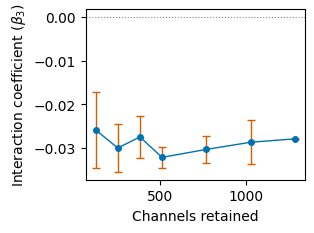

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

dose_df = pd.read_csv("/content/drive/MyDrive/CASIA2.0/channel_dose_response.csv")

output_dir = "/content/drive/MyDrive/CASIA2.0/figures"
os.makedirs(output_dir, exist_ok=True)

COL_WIDTH = 3.25
COLOR_A = "#0072B2"
COLOR_B = "#D55E00"

fig, ax = plt.subplots(figsize=(COL_WIDTH, COL_WIDTH * 0.75))
means = dose_df.groupby("k")["coef"].mean()
stds = dose_df.groupby("k")["coef"].std().fillna(0)

ax.errorbar(means.index, means.values, yerr=stds.values, marker="o", markersize=4,
            color=COLOR_A, ecolor=COLOR_B, capsize=3, linewidth=1)
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Channels retained")
ax.set_ylabel(r"Interaction coefficient ($\beta_3$)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "dose_response.pdf"))
plt.show()

## Final summary

Fill in after the dose-response cell finishes: does `summary` show a roughly monotonic trend (coefficient magnitude shrinking as channel count increases from 128 toward 1280)? If so, this is a dose-response relationship between channel dimensionality and the measured effect — stronger evidence for channel-count dilution than the two-point (512 vs. 1280) comparison alone. Report it in the paper as exactly that: a systematic trend across 7 channel-count levels with 5 random draws per level (reused deterministic result at k=1280), not as independent replications.